## ✅ TASK 1: Web Scraping 
### 
### ● Use Python libraries like BeautifulSoup or Scrapy to extract data from websites. 
### ● Identify and collect relevant datasets from public web pages. 
### ● If you don’t code, use automated tools like Octoparse or ParseHub. 
### ● Learn to handle HTML structure and web navigation to gather accurate data. 
### ● Create custom datasets tailored to specific analysis needs. 

In [22]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

base = "http://books.toscrape.com/catalogue/"
start_url = "http://books.toscrape.com/catalogue/page-1.html"

books_data = []

url = start_url
while url:
    print("Scraping:", url)
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    
    books = soup.find_all("article", class_="product_pod")

    for b in books:
        title = b.h3.a["title"]
        price = b.find("p", class_="price_color").text
        stock = b.find("p", class_="instock availability").text.strip()
        rating = b.find("p")["class"][1]
        link = base + b.h3.a["href"]

        books_data.append({
            "title": title,
            "price": price,
            "stock": stock,
            "rating": rating,
            "url": link
        })

    
    next_button = soup.find("li", class_="next")
    if next_button:
        next_page = next_button.a["href"]
        url = base + next_page
    else:
        url = None


df = pd.DataFrame(books_data)
df.head()


Scraping: http://books.toscrape.com/catalogue/page-1.html
Scraping: http://books.toscrape.com/catalogue/page-2.html
Scraping: http://books.toscrape.com/catalogue/page-3.html
Scraping: http://books.toscrape.com/catalogue/page-4.html
Scraping: http://books.toscrape.com/catalogue/page-5.html
Scraping: http://books.toscrape.com/catalogue/page-6.html
Scraping: http://books.toscrape.com/catalogue/page-7.html
Scraping: http://books.toscrape.com/catalogue/page-8.html
Scraping: http://books.toscrape.com/catalogue/page-9.html
Scraping: http://books.toscrape.com/catalogue/page-10.html
Scraping: http://books.toscrape.com/catalogue/page-11.html
Scraping: http://books.toscrape.com/catalogue/page-12.html
Scraping: http://books.toscrape.com/catalogue/page-13.html
Scraping: http://books.toscrape.com/catalogue/page-14.html
Scraping: http://books.toscrape.com/catalogue/page-15.html
Scraping: http://books.toscrape.com/catalogue/page-16.html
Scraping: http://books.toscrape.com/catalogue/page-17.html
Scrapi

,title,price,stock,rating,url
0,A Light in the Attic,Â£51.77,In stock,Three,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,Â£53.74,In stock,One,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,Â£50.10,In stock,One,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,Â£47.82,In stock,Four,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,Five,http://books.toscrape.com/catalogue/sapiens-a-...


In [24]:
df.describe()

,title,price,stock,rating,url
count,1000,1000,1000,1000,1000
unique,999,903,1,5,1000
top,The Star-Touched Queen,Â£44.18,In stock,One,http://books.toscrape.com/catalogue/1000-place...
freq,2,3,1000,226,1


In [39]:
## Renaming the columns
df.rename(columns={
    'title': 'Title',
    'price': 'Price',
    'stock': 'Stock',
    'rating': 'Ratings',
    'url': 'URL'
}, inplace=True)


In [26]:
### Converting Rating Values in word to Numerical values

df['Ratings'].replace({
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}, inplace=True)


C:\Users\Owner\AppData\Local\Temp\ipykernel_15444\237832770.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ratings'].replace({
C:\Users\Owner\AppData\Local\Temp\ipykernel_15444\237832770.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Ratings'].replace({


In [27]:
df

,Title,Price,Stock,Ratings,URL
0,A Light in the Attic,Â£51.77,In stock,3,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,Â£53.74,In stock,1,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,Â£50.10,In stock,1,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,Â£47.82,In stock,4,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,Â£54.23,In stock,5,http://books.toscrape.com/catalogue/sapiens-a-...
...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,Â£55.53,In stock,1,http://books.toscrape.com/catalogue/alice-in-w...
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",Â£57.06,In stock,4,http://books.toscrape.com/catalogue/ajin-demi-...
997,A Spy's Devotion (The Regency Spies of London #1),Â£16.97,In stock,5,http://books.toscrape.com/catalogue/a-spys-dev...
998,1st to Die (Women's Murder Club #1),Â£53.98,In stock,1,http://books.toscrape.com/catalogue/1st-to-die...


In [29]:
df["Price"] = df["Price"].astype(str).str.replace("Â£", "", regex=False).str.replace("£", "", regex=False)
df["Price"] = df["Price"].astype(float)


In [30]:
df.head(10)

,Title,Price,Stock,Ratings,URL
0,A Light in the Attic,51.77,In stock,3,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,53.74,In stock,1,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,50.10,In stock,1,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,47.82,In stock,4,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,http://books.toscrape.com/catalogue/sapiens-a-...
5,The Requiem Red,22.65,In stock,1,http://books.toscrape.com/catalogue/the-requie...
6,The Dirty Little Secrets of Getting Your Dream...,33.34,In stock,4,http://books.toscrape.com/catalogue/the-dirty-...
7,The Coming Woman: A Novel Based on the Life of...,17.93,In stock,3,http://books.toscrape.com/catalogue/the-coming...
8,The Boys in the Boat: Nine Americans and Their...,22.60,In stock,4,http://books.toscrape.com/catalogue/the-boys-i...
9,The Black Maria,52.15,In stock,1,http://books.toscrape.com/catalogue/the-black-...


In [31]:
## Saving the product as csv
df.to_csv("books_scraped.csv", index=False, encoding="utf-8-sig", sep=",")


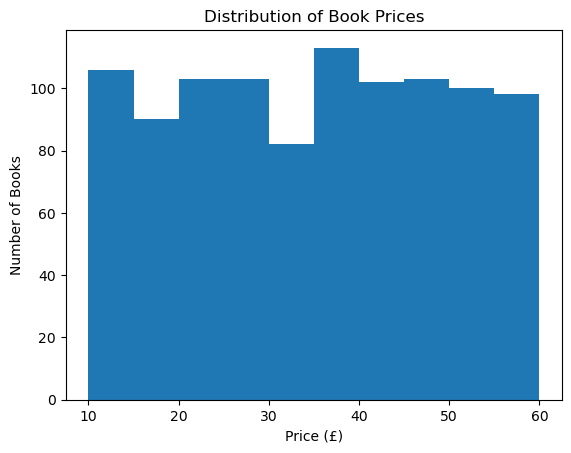

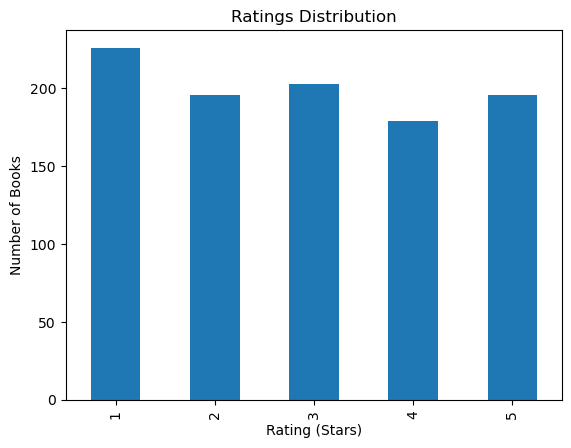

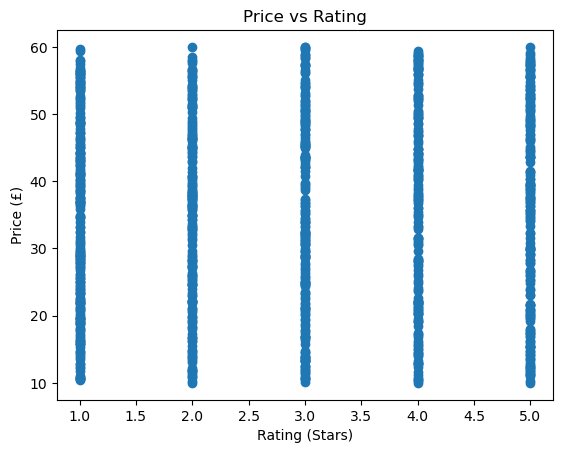

In [38]:
import matplotlib.pyplot as plt

plt.hist(df["Price"])
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Prices")
plt.show()

df["Ratings"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Books")
plt.title("Ratings Distribution")
plt.show()

plt.scatter(df["Ratings"], df["Price"])
plt.xlabel("Rating (Stars)")
plt.ylabel("Price (£)")
plt.title("Price vs Rating")
plt.show()
